<a href="https://colab.research.google.com/github/ChanchalSaha48/nlp-learning-journey/blob/main/03_machine_learning/03_LinearSVC/IMDb_movie_Review_using_Linear_SVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMDb Movie Review using Baseline Model(LinearSVC)

In [1]:
!pip install Opendatasets

In [2]:
import warnings
warnings.filterwarnings('ignore')


In [3]:
#======================================
# Import libraries
#======================================
import opendatasets as od

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [4]:
od.download('https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')

Skipping, found downloaded files in "./imdb-dataset-of-50k-movie-reviews" (use force=True to force download)


# Load Dataset

In [5]:
df=pd.read_csv('/content/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Preprocessing

In [6]:

from bs4 import BeautifulSoup
def preprocessing(text):
  text=BeautifulSoup(text,'html.parser').get_text()
  text=text.lower()
  return text


In [7]:
df['review']=df['review'].apply(preprocessing)

In [8]:
df['label']=df['sentiment'].map({
    'negative':0,
    'positive':1
})

In [9]:
df.head()

,review,sentiment,label
0,one of the other reviewers has mentioned that ...,positive,1
1,a wonderful little production. the filming tec...,positive,1
2,i thought this was a wonderful way to spend ti...,positive,1
3,basically there's a family where a little boy ...,negative,0
4,"petter mattei's ""love in the time of money"" is...",positive,1


## Spliting Dataset

In [10]:
x_train,x_test,y_train,y_test=train_test_split(df['review'],df['label'],test_size=0.2,random_state=42,stratify=df['label'])

In [11]:
print("Train shape: ",x_train.shape)
print("Test shape: ",x_test.shape)

Train shape:  (40000,)
Test shape:  (10000,)


## TF-IDF

In [12]:
tfidf=TfidfVectorizer(max_features=20000)

In [13]:
x_train_tfidf=tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)

## Build Model

In [14]:
model=LinearSVC()

In [15]:
model.fit(x_train_tfidf,y_train)

LinearSVC()

In [16]:
y_pred=model.predict(x_test_tfidf)


In [17]:
acc=accuracy_score(y_test,y_pred)
pre=precision_score(y_test,y_pred)
rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [18]:
print("Accuracy: ",acc)
print("Precision: ",pre)
print("Recall: ",rec)
print("F1-Score: ",f1)

Accuracy:  0.8997
Precision:  0.8964491172386432
Recall:  0.9038
F1-Score:  0.9001095508415496


In [19]:
cm=confusion_matrix(y_test,y_pred)


Text(0.5, 1.0, 'Confusion Matrix')

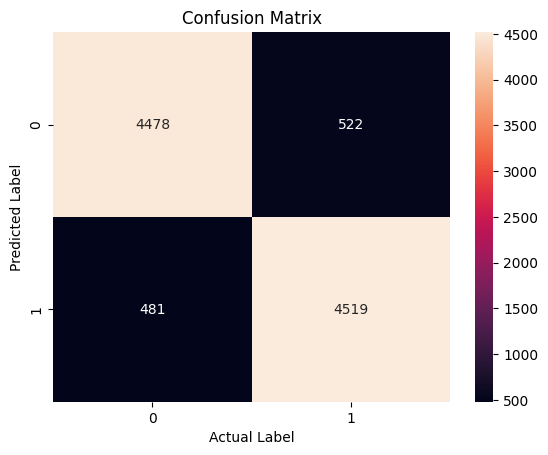

In [20]:
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Actual Label")
plt.ylabel("Predicted Label")
plt.title("Confusion Matrix")


In [21]:
cl=classification_report(y_test,y_pred,labels=['negative','positive'])

In [22]:
print("Classification report: ",cl)

Classification report:                precision    recall  f1-score   support

    negative       0.00      0.00      0.00         0
    positive       0.00      0.00      0.00         0

   micro avg       0.00      0.00      0.00         0
   macro avg       0.00      0.00      0.00         0
weighted avg       0.00      0.00      0.00         0



In [23]:
cm

array([[4478,  522],
       [ 481, 4519]])